# Notebook to Demonstrate NISAR Cal/Val Database GPS Access for Greenland Data
---

This demonstrates and tests the capability of the nisarSation class for working with GPS data processed by JPL for NISAR cryo cal/val activities.

## Python Setup

In [10]:
%load_ext autoreload
%autoreload 2
import time
#
reset = False
try:
    import nisarcryodb
except Exception:
    %pip install -e ~/./nisarcryodb
    reset = True
try:
    import nisargps
except Exception:
    %pip install -e ~/./nisargps
    reset = True
if reset:
    print('\n\033[1;31m\n\nRestart kernel and run this cell again \n\n \033[0m\n''')
    time.sleep(1e9) # stop from advancing

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
%load_ext autoreload
%autoreload 2
import numpy as np
import nisargps
import nisarcryodb
import matplotlib.pyplot as plt
from datetime import timedelta, datetime
import pyproj
from scipy.stats import linregress
import calendar
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
def decimalYearToDateTime(date):
    if date is np.nan:
        return None
    year = int(date)
    fracYear = date - year
    yearLength = (datetime(year + 1, 1, 1) - datetime(year, 1, 1)).total_seconds() 
    return datetime(year, 1, 1) + timedelta(seconds=fracYear * yearLength)

## Load Data

Station data too big for github, so unzip if compressed after downloading.

Setup station id and path.

In [13]:
configFile = '../nisarcryodb/Notebooks/calvaldb_config.ini'

In [14]:
DB = nisarcryodb.nisarcryodb(configFile=configFile)

User name:  irj
Password:  ········


## Find Stations with Data

In [15]:
if False:  # set True to run this step
    d1 = 2018.0
    d2 = 2030.0
    stations = DB.getColumn('landice', 'gps_station', 'station_name')
    for station in stations:
        if 'test' not in station:
            myData = DB.getStationDateRangeData(station, d1, d2, 'landice', 'gps_data')
            minDate = decimalYearToDateTime(np.min(myData['decimal_year']) )
            maxDate = decimalYearToDateTime(np.max(myData['decimal_year']) )
            
            if minDate is not None:
                print(station, myData['station_id'][0], len(myData['station_id']), end='\t')
                print(minDate.strftime('%Y-%m-%d'), maxDate.strftime('%Y-%m-%d'))


## Setup NIT1

Pass in the already open DB rather than having the station open its own DB connection

In [16]:
%%time
stationName = 'NIT1'
stationNIT1 = nisargps.nisarStation(stationName, DBConnection=DB, traceBack=False)

2
Caching station data
station_id
CPU times: user 5.14 s, sys: 676 ms, total: 5.82 s
Wall time: 7.82 s


In [20]:
stationNIT1.DBData.drop(columns=['data_geom'], errors='ignore').to_parquet('NIT1_DBData.parquet', index=False)


In [18]:
stationNIT1.DBData

,gps_data_id,station_id,version_id,time_utc,lat,lon,time_tai,height_arp,x,y,...,perm_tide_rad,load_tide_fes,load_tide_got,ocean_tide_fes,ocean_tide_got,pole_tide,model_dry_tropo_cor,model_wet_tropo_cor,gnss_wet_tropo_cor,data_geom
0,1144482,2,12,2025-10-01 00:00:12,-79.793409,161.346030,2025-10-01 00:00:49,-1.649347,-1.074309e+06,362671.976122,...,-0.114934,-0.001369,0.001071,0.246946,0.279183,-0.00272,-2.215161,-0.023010,-0.033508,0101000020E6100000631812AE122B6440907B2637C7F2...
1,1144483,2,12,2025-10-01 00:00:42,-79.793409,161.346030,2025-10-01 00:01:19,-1.624299,-1.074309e+06,362671.982596,...,-0.114934,-0.001337,0.001101,0.245839,0.278188,-0.00272,-2.215156,-0.023011,-0.033510,0101000020E61000009E869DAD122B6440B16F0837C7F2...
2,1144484,2,12,2025-10-01 00:01:12,-79.793409,161.346030,2025-10-01 00:01:49,-1.644724,-1.074309e+06,362671.983386,...,-0.114934,-0.001304,0.001131,0.244731,0.277192,-0.00272,-2.215152,-0.023013,-0.033512,0101000020E6100000AADB4FAD122B644007CE1F37C7F2...
3,1144485,2,12,2025-10-01 00:01:42,-79.793409,161.346030,2025-10-01 00:02:19,-1.641013,-1.074309e+06,362671.987129,...,-0.114934,-0.001272,0.001161,0.243623,0.276195,-0.00272,-2.215147,-0.023014,-0.033514,0101000020E6100000AAE2F1AC122B64400C271837C7F2...
4,1144486,2,12,2025-10-01 00:02:12,-79.793409,161.346030,2025-10-01 00:02:49,-1.661011,-1.074309e+06,362671.985442,...,-0.114934,-0.001239,0.001191,0.242513,0.275197,-0.00272,-2.215142,-0.023016,-0.033515,0101000020E6100000D3F52CAD122B64404009EA36C7F2...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500221,88287,2,11,2025-09-30 23:57:12,-79.793409,161.346030,2025-09-30 23:57:49,-1.647000,-1.074309e+06,362671.976163,...,-0.114934,-0.001564,0.000892,0.253570,0.285124,-0.00272,-2.215180,-0.022987,-0.032282,0101000020E6100000CDF45FAE122B64402838D636C7F2...
500222,88288,2,11,2025-09-30 23:57:42,-79.793409,161.346030,2025-09-30 23:58:19,-1.629711,-1.074309e+06,362671.982172,...,-0.114934,-0.001531,0.000922,0.252469,0.284137,-0.00272,-2.215177,-0.022991,-0.032286,0101000020E610000085D795AD122B64407F361437C7F2...
500223,88289,2,11,2025-09-30 23:58:12,-79.793409,161.346030,2025-09-30 23:58:49,-1.636494,-1.074309e+06,362671.977486,...,-0.114934,-0.001499,0.000952,0.251366,0.283149,-0.00272,-2.215174,-0.022995,-0.032290,0101000020E6100000935C2DAE122B644061F8F536C7F2...
500224,88290,2,11,2025-09-30 23:58:42,-79.793409,161.346030,2025-09-30 23:59:19,-1.636676,-1.074309e+06,362671.977674,...,-0.114934,-0.001466,0.000982,0.250262,0.282159,-0.00272,-2.215171,-0.022999,-0.032293,0101000020E6100000756112AE122B6440ACB20C37C7F2...


Load a sample data set. Can be accessed as `stationNIT1.x` (or `.y, .z, .lat, .lon, .date, .epoch`), where `date` provides the date as `datetime` array and `epoch` provides the date as a decimal year.

In [9]:
data = stationNIT1.subsetXYZ('2024-05-01 21:01:01', '2024-05-27 03:59:59', dateFormat='%Y-%m-%d %H:%M:%S', minPoints=1, traceBack=True)


*************************************************
Error in: nisarStation._subsetXYZDB at line 3648 
Message: 'decimal_year' 
*************************************************
 



SystemExit: 

/opt/conda/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## Plot Positions

This function plots the relative trajectories of the GPS and computes the velocity two ways 1) `regression`, which uses the slope of the linear fit to the data, and 2) `point`, which uses the difference of the end points divided by time. For this latter method, you can control how many points at the end to average.

In [8]:
def demoPlot(station, date1, date2):
    # Get points
    date, x, y, z, epoch = stationNIT1.subsetXYZ(date1, date2, sigmaMultiple=3)
    # Regression estimagte
    vx, vy, xMean, yMean = stationNIT1.computeVelocity(date1, date2, method='regression', dateFormat="%Y-%m-%d %H:%M:%S")
    # Get date extremes
    minDate = np.min(date).strftime('%Y-%m-%d')
    maxDate = np.max(date).strftime('%Y-%m-%d')
    # Do regression to demo (for plot only, not velocity estimate)
    resultx = linregress(epoch, x)
    resulty = linregress(epoch, y)
    # Compute linear path
    xline = resultx[0] * epoch + resultx[1]
    yline = resulty[0] * epoch + resulty[1]
    # Plot points
    fig, ax = plt.subplots(1, 1, figsize=(20, 10))
    ax.plot(x - xline, y - yline, 'r.', markersize=5, label='Regression Points')
    print(np.std(x - xline), np.std(y - yline))
    # Compute end point velocities
    #for ap, dy, color, markersize in zip([12, 3], [0.045, 0.09], ['black', 'blue'],[3, 3]):
        #continue
    #    dT = timedelta(days=ap)
    #    vxPt, vyPt, xMeanPt, yMeanPt = stationNIT1.computeVelocity(date1, date2, method='point', dateFormat="%Y-%m-%d %H:%M:%S", averagingPeriod=24*ap)
    #    ax.text(0.02, 0.03+dy, f'Point $\\pm${ap}days: vx={vxPt:.1f}, vy={vyPt:.1f}, v={np.sqrt(vxPt**2 + vyPt**2):.1f}',transform=ax.transAxes, fontsize=18)
   #    label = f'$\\pm${ap} end points'
     #   for myDate in [date1, date2]:
    #        dateX, x1, y1, z1, epoch1 = stationNIT1.subsetXYZ(myDate-dT, myDate+dT, sigmaMultiple=3)
     #       ax.plot(x1 - x[0], y1 - y[0], '.', color=color, markersize=markersize, label=label)
     #       label = None
    # Plot regression
    #ax.plot(xline-x[0], yline-y[0], 'orange', linewidth=2, label='Regression')
    # Decorate plot
    ax.set_xlabel('X (m)', fontsize=16)
    ax.set_ylabel('Y (m)', fontsize=16)
    ax.text(0.02, 0.03, f'Regression: vx={vx:.1f}, vy={vy:.1f}, v={np.sqrt(vx**2 + vy**2):.1f}',transform=ax.transAxes, fontsize=18)
    ax.legend()
    ax.set_title(f'Station {stationNIT1.stationName} Trajectory from {minDate} to {maxDate}', fontsize=14) 
    for lab  in ax.get_xticklabels() + ax.get_yticklabels():
        lab.set_fontsize(14)

Plot June data when there are continuous data.

EPSG 3031
0.016490624715034933 0.011521193465879464


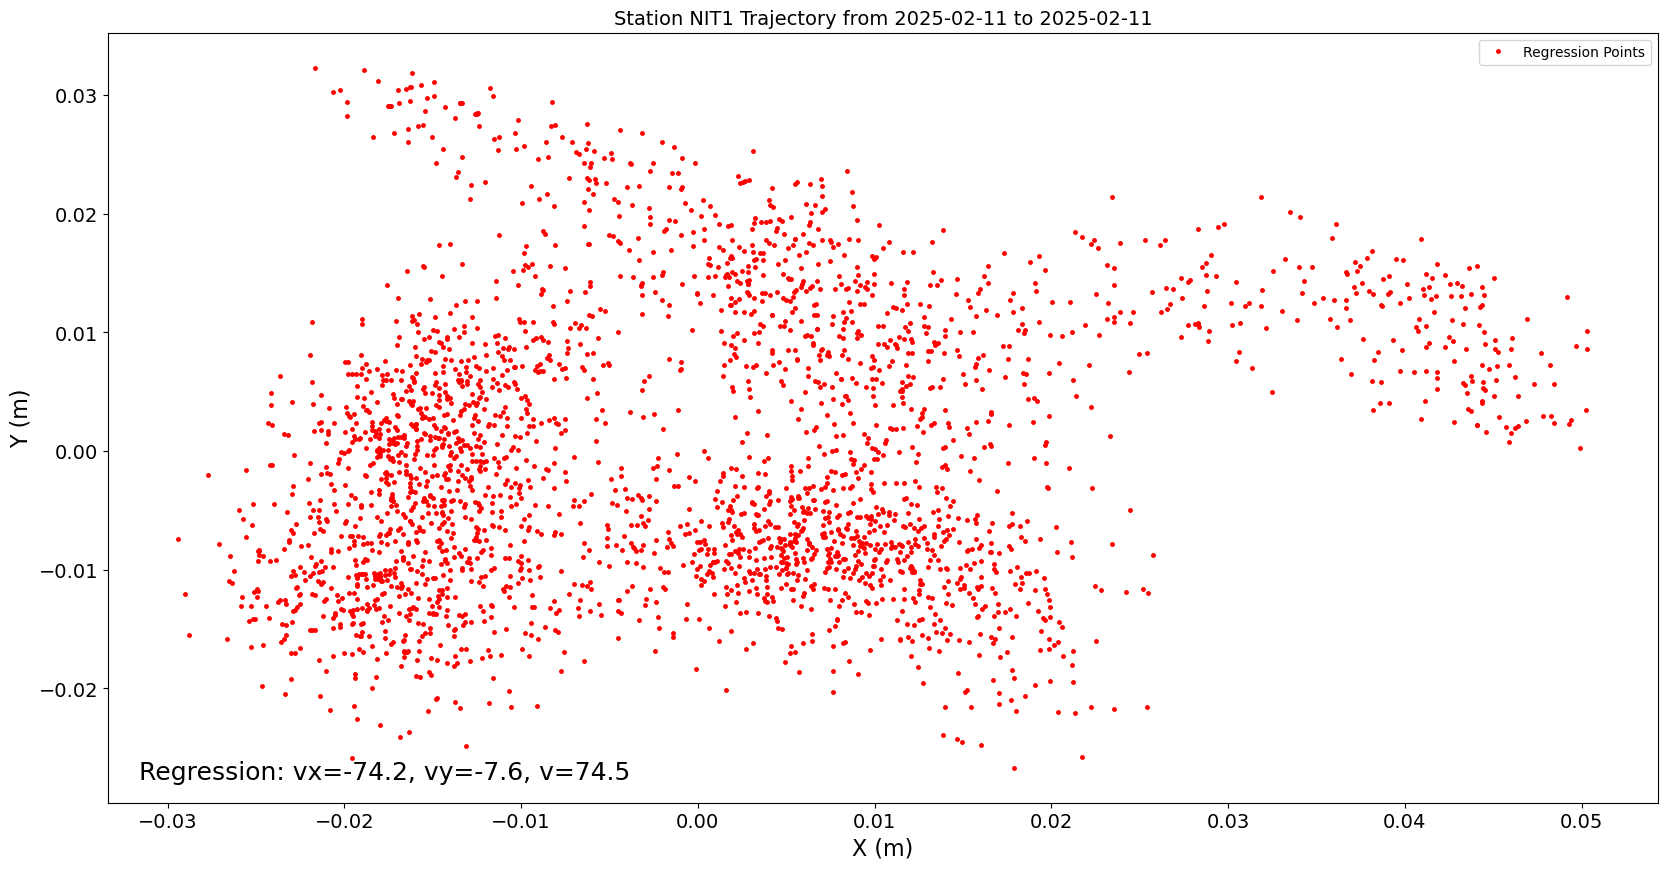

In [9]:
date1 = datetime(2025, 2, 11, 0, 0, 0)
date2 = datetime(2025, 2, 11, 23, 59, 59)

demoPlot(stationNIT1, date1, date2)

## Compute and Plot Time Series

This section demonstrates the estimate of a velocity time series over a given period. There are two methods:
- `point`, which computes the position averaged over some interval (`averagingPeriod`)
- `regression` this method computes the velocity of slope for all the points over the period of interest.

The method is specified with the `method` keyword. Either method generates the series from `date1` to `date2`, sampled at increments of `sampleInterval` hours. Velocities are computed with a `dT` specfied in hours. Further research is needed to best determine the velocity for NISAR cal/val. In this example, the standard deviations of the velocities computed using the two methods are 0.6 and 1.7 m/yr, respectively. The differences arise because of the large diurnal variation in speed on the floating ice. The results should be much better on grounded ice. 

The method and period are specified as:

In [29]:
#method = 'point'
method = 'regression'
date1 = '2024-12-01' 
date2 = '2025-01-15'
tides=False

Compute velocity at various intervals and over various periods.

Compute velocity time series at daily intervals.

In [30]:
x1, y1 = stationNIT1.lltoxy(67.11978174, -47.13914107)
x2, y2 = stationNIT1.lltoxy(67.1197820947545, -47.13914039991905)
print(x2-x1, y2-y1)

-0.22508477419614792 1.1779505386948586


In [31]:
sampleInterval = 6 # Estimate every 4 hours
dT = 24  # Compute over a 24 hour interval
dateDaily, vxDaily, vyDaily, x, y = stationNIT1.computeVelocityTimeSeries(date1, date2,
                                                                    dT, sampleInterval, method=method, tides=tides)
print(f'Sigma X, Y {np.nanstd(vxDaily):.3} (m), {np.nanstd(vyDaily):.3} (m)')

Sigma X, Y 31.5 (m), 19.1 (m)


Now compute at daily intervals but with delta T of 12 days.

In [33]:
sampleInterval = 12 # Estimate every 12 hours
dT = 24 * 12  # Compute speed over 12 day interval
date12, vx12, vy12, x12, y12 = stationNIT1.computeVelocityTimeSeries(date1, date2,
                                                           dT, sampleInterval, method=method, tides=tides)
print(f'Sigma X, Y {np.nanstd(vx12):.3}, {np.nanstd(vy12):.3}')

Sigma X, Y 1.94, 0.461


Now Plot the results.

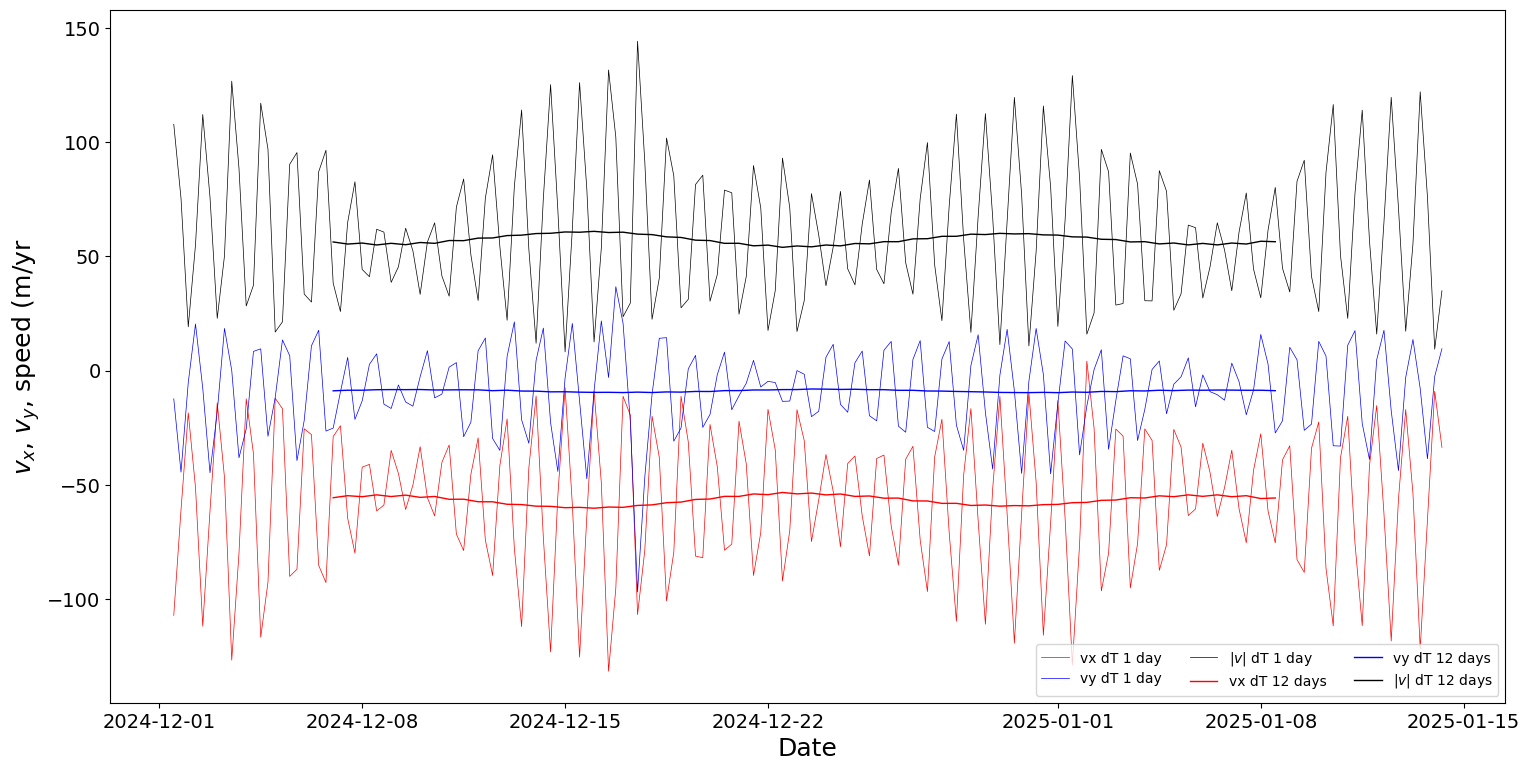

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(18, 9))
for date, vx, vy, dTLabel, marker, linewidth in zip([ dateDaily, date12],
                                         [ vxDaily, vx12], 
                                         [ vyDaily, vy12],
                                         ['dT 1 day', 'dT 12 days'], 
                                         ['-', '-', 'o'], [.5, 1, 1]):
    ax.plot(date, vx, f'r{marker}', label=f'vx {dTLabel}', markersize=4, linewidth=linewidth)
    ax.plot(date, vy, f'b{marker}', label=f'vy {dTLabel}', markersize=4, linewidth=linewidth)
    ax.plot(date, np.sqrt(vx**2 + vy**2), f'k{marker}', label=f'$|v|$ {dTLabel}', markersize=4, linewidth=linewidth)
#
ax.set_ylabel('$v_x$, $v_y$, speed (m/yr', fontsize=18)  
ax.set_xlabel('Date', fontsize=18)
for lab  in ax.get_xticklabels() + ax.get_yticklabels():
    lab.set_fontsize(14)
ax.legend(loc='lower right', ncol=3)

As the results indicate, there is there is a large diurnal variation for the daily solutions, which are probably some kind of tide. It should be reduced with the new de-tided data from Ron. The 12-day estimates are quite stable with $\sigma$ of ~30 cm/yr. 

In [16]:

print(d1, d2)

NameError: name 'd1' is not defined

In [ ]:
dates = []
for year in range(2023, 2026):
    for month in range(1, 13):
        dates.append(datetime(year, month, 1))

In [ ]:
%%time
d1 = stationNIT1._datetimeToDecimalYear(datetime(2023,1,1))
d2 = stationNIT1._datetimeToDecimalYear(datetime(2026,1,1))
myData = stationNIT1.DB.getStationDateRangeData(stationNIT1.stationName, d1, d2,'landice', 'gps_data')



In [ ]:
%%time
for date1, date2 in zip(dates[0:-2], dates[1:-1]):
    x = myData[(myData["decimal_year"] > d1) & (myData["decimal_year"] < d2)]

        

In [ ]:
%%time
for date1, date2 in zip(dates[0:-2], dates[1:-1]):
    d1 = stationNIT1._datetimeToDecimalYear(date1)
    d2 = stationNIT1._datetimeToDecimalYear(date2)
    x =stationNIT1.DB.getStationDateRangeData(stationNIT1.stationName, d1, d2,
                                               'landice', 'gps_data')

In [ ]:
x

In [ ]:
mem_MB = myData.memory_usage(deep=True).sum() / (1024**2)
print(f"{mem_MB:.2f} MB")

In [ ]:
print(np.max(myData['version_id']))

In [ ]:
%%time
myID = stationNIT1.DB.stationNameToID('NIT1')
myData1 = stationNIT1.DB.getTableListing(schemaName='landice', tableName='gps_data', filters={'station_id': 5})

In [ ]:
stationNIT1.stationID

In [ ]:
myData1.station_id[1]

In [ ]:
d = {}
def test(d1):
    d1['x'] =1
test(d)
print(d)

In [9]:
date, x, y, z, epoch = stationNIT1.subsetXYZ('2025-02-11 00:00:00', '2025-02-11  23:59:59', dateFormat='%Y-%m-%d %H:%M:%S', minPoints=1, traceBack=True, tides=False)
date1, x1, y1, z1, epoch = stationNIT1.subsetXYZ('2025-02-11 00:00:00', '2025-02-11 23:59:59', dateFormat='%Y-%m-%d %H:%M:%S', minPoints=1, traceBack=True, tides=True)

EPSG 3031
tides


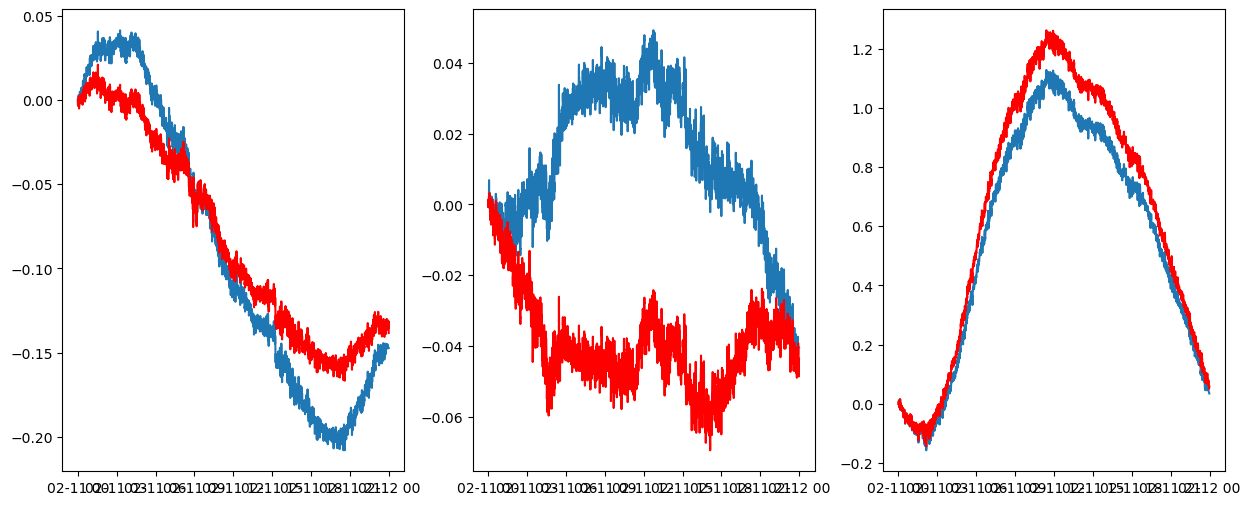

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for v, v1, ax in zip([x, y, z], [x1, y1, z1], axes.flatten()):
    ax.plot(date, v-v[0], label='with tides')
    ax.plot(date1, v1-v1[0], 'r', label='tides removed')